## 12.

(e) Apply the method to an image of your choice and briefly comment on:
• Illumination correction
• Contrast enhancement
• Any artifacts observed

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [13]:
f = cv.imread(r'C:\Users\94775\Desktop\msc\Semester III\Computer Vision\258764G\runway.png', cv.IMREAD_GRAYSCALE) #IMREAD_COLOR --> open the image as a colored one
assert f is not None, 'Image not found' #If the image not found

In [14]:
# Step 1: Log transform
z = np.log1p(f.astype(np.float32))

In [15]:
# Step 2: FFT
Z = np.fft.fft2(z)
Z_shifted = np.fft.fftshift(Z)

In [16]:
# Step 3: Gaussian high-pass filter
M, N = f.shape
u = np.arange(-M//2, M//2)
v = np.arange(-N//2, N//2)
V, U = np.meshgrid(v, u)
gamma_L, gamma_H, sigma = 0.5, 2.0, 30
H = (gamma_H - gamma_L) * (1 - np.exp(-(U**2 + V**2)/(2*sigma**2))) + gamma_L

In [17]:
# Step 4: Apply filter
G_shifted = H * Z_shifted
g = np.fft.ifft2(np.fft.ifftshift(G_shifted)).real

In [18]:
# Step 5: Inverse log
output = np.expm1(g)
output = cv.normalize(output, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

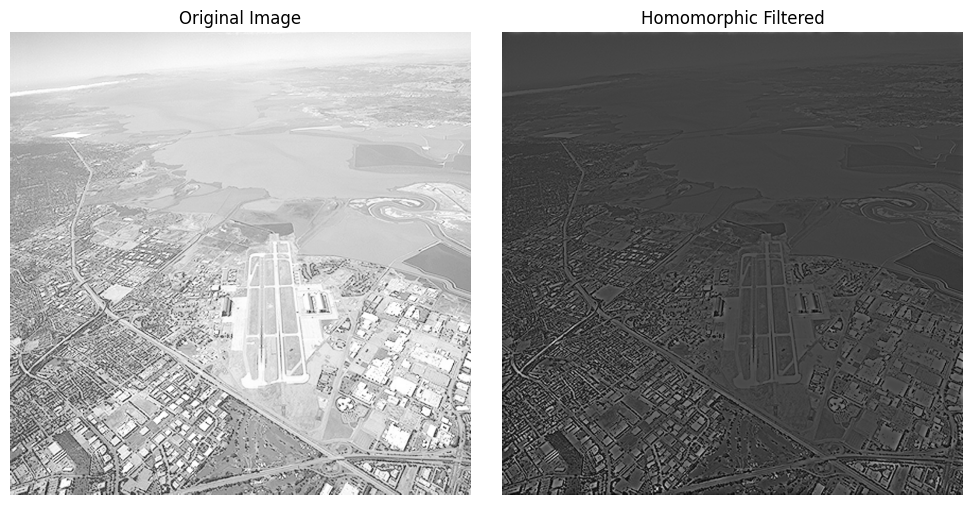

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(output, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Homomorphic Filtered')
ax[1].axis('off')

plt.tight_layout()
plt.show()